# 03 - Baseline CNN (from scratch)

This notebook trains and evaluates a small CNN from scratch as a baseline for fake currency detection.

In [7]:
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models

baseline_model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),

    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid"),
])

baseline_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,938,561 (49.36 MB)

 Trainable params: 12,938,561 (49.36 MB)

 Non-trainable params: 0 (0.00 B)

## Load the processed dataset

The generators resize images to the model input shape and normalize pixel values to `[0, 1]`. The validation generator has no augmentation.

In [8]:
from pathlib import Path
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
DATA_DIR = Path('..') / 'data' / 'processed'
TRAIN_DIR = DATA_DIR / 'train'
VAL_DIR = DATA_DIR / 'val'

train_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
)
val_datagen = ImageDataGenerator(rescale=1.0 / 255.0)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True,
)
val_generator = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False,
)

print('Class indices:', train_generator.class_indices)
print('Training images:', train_generator.samples)
print('Validation images:', val_generator.samples)

Found 1280 images belonging to 2 classes.
Found 320 images belonging to 2 classes.
Class indices: {'Fake Notes': 0, 'Real Notes': 1}
Training images: 1280
Validation images: 320


## Compile and train

In [9]:
# Compile the model
baseline_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy'],
)



In [10]:
history = baseline_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 98s 2s/step - accuracy: 0.6219 - loss: 0.8583 - val_accuracy: 0.7063 - val_loss: 0.5949
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 90s 2s/step - accuracy: 0.7422 - loss: 0.5244 - val_accuracy: 0.7250 - val_loss: 0.5637
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 90s 2s/step - accuracy: 0.7570 - loss: 0.4866 - val_accuracy: 0.7000 - val_loss: 0.5615
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 139s 4s/step - accuracy: 0.7773 - loss: 0.4713 - val_accuracy: 0.7344 - val_loss: 0.5356
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 110s 3s/step - accuracy: 0.7969 - loss: 0.4452 - val_accuracy: 0.7781 - val_loss: 0.5058
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 89s 2s/step - accuracy: 0.8430 - loss: 0.3796 - val_accuracy: 0.7625 - val_loss: 0.6313
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 90s 2s/step - accuracy: 0.8570 - loss: 0.3416 - val_accuracy: 0.8125 - val_loss: 0.4837
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 89s 2s/step - accuracy: 0.8336 - loss: 0.4077 - val_accuracy: 0.8250 - val_los

In [11]:
baseline_model.save('../models/baseline_cnn.keras')
print('Saved baseline model to ../models/baseline_cnn.keras')

Saved baseline model to ../models/baseline_cnn.keras


## Evaluate the baseline

In [12]:
val_generator.reset()
val_loss, val_accuracy = baseline_model.evaluate(val_generator, verbose=1)
print(f'Validation loss: {val_loss:.4f}')
print(f'Validation accuracy: {val_accuracy:.4f}')

10/10 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.8188 - loss: 0.4386
Validation loss: 0.4386
Validation accuracy: 0.8188


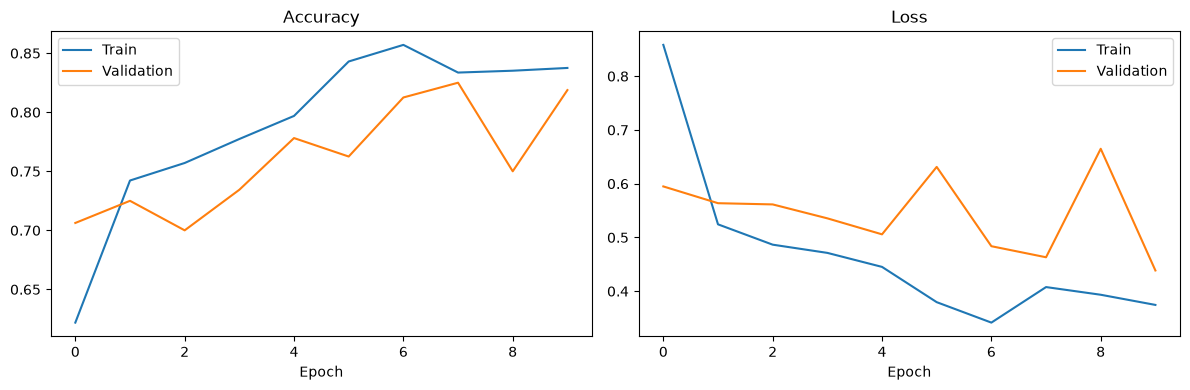

In [13]:
if 'history' not in globals():
    print('Training history is not available. Run the compile and training cells above first.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history.history['accuracy'], label='Train')
    axes[0].plot(history.history['val_accuracy'], label='Validation')
    axes[0].set_title('Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()

    axes[1].plot(history.history['loss'], label='Train')
    axes[1].plot(history.history['val_loss'], label='Validation')
    axes[1].set_title('Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

## Baseline CNN Results
- Final validation accuracy: ~82%
- Final validation loss: ~0.44 (but fluctuated significantly during training, 0.43-0.68)
- Observation: Validation loss instability suggests the model struggles to
  generalize consistently from scratch on this dataset size (1280 training
  images). This motivates trying transfer learning next.